# Inspect `smooth_hybrid_train_test`

This notebook is a forensic run for the `smooth_hybrid_train_test` variant.

It is meant to answer four debugging questions:

1. Is the model systematically underbidding?
2. Is it saturating on the action grid edges?
3. Is the bid mostly determined by clipping (`max_bid` or `balance`) rather than by the learned policy?
4. How much click volume is left on the table at the same hour if we bid up to the available upper bound?

Artifacts are saved into `outputs/smooth_hybrid_train_test_debug/` and include:

- trained model checkpoint
- training diagnostics CSV
- step-level eval debug CSV
- eval history CSV
- per-step counterfactual CSV
- campaign summary CSV
- summary JSON
- debug figures PNG


In [1]:
import json
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from IPython.display import display
from tqdm.auto import tqdm

notebook_dir = Path().resolve()
example_notebooks_dir = notebook_dir.parent.parent
bat_autobidding_dir = example_notebooks_dir.parent

if str(example_notebooks_dir) not in sys.path:
    sys.path.insert(0, str(example_notebooks_dir))
if str(bat_autobidding_dir) not in sys.path:
    sys.path.insert(0, str(bat_autobidding_dir))

from experiments.exp_configs import RND42TrainTestHybridSmoothConfig
from simulator.model.drlb_bidder import DRLBBidder
from simulator.simulation.simulate import simulate_campaign
from simulator.simulation.utils import price2bin
from simulator.validation.check_results import create_campaign_instance
from simulator.validation.metrics import compile_metrics

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)


/Users/amsafin/code/local_ml/rl/bat_venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
config = RND42TrainTestHybridSmoothConfig()
config.ensure_artifact_dirs()
config.config_dir.mkdir(parents=True, exist_ok=True)

OBJECTIVE = "clicks"
EXP_TYPE = "improved_hybrid_drlb_smooth_eval"
RUN_LABEL = "smooth_hybrid_train_test_debug"
FORCE_RETRAIN = False
MAX_TRAIN_STEPS = None
MAX_DEBUG_CAMPAIGNS = None  # Set an integer for a faster smoke run.
MEAN_CLICK_PRICE = 5.0

DEBUG_DIR = config.outputs_dir / RUN_LABEL
DEBUG_DIR.mkdir(parents=True, exist_ok=True)
MODEL_PATH = DEBUG_DIR / f"{RUN_LABEL}.pt"
TRAIN_DIAGNOSTICS_PATH = DEBUG_DIR / f"{RUN_LABEL}_training_diagnostics.csv"
TRAIN_METRICS_PATH = DEBUG_DIR / f"{RUN_LABEL}_training_metrics.json"
EVAL_STEPS_PATH = DEBUG_DIR / f"{RUN_LABEL}_eval_steps.csv"
EVAL_HISTORY_PATH = DEBUG_DIR / f"{RUN_LABEL}_eval_history.csv"
COUNTERFACTUAL_PATH = DEBUG_DIR / f"{RUN_LABEL}_counterfactual_steps.csv"
CAMPAIGN_SUMMARY_PATH = DEBUG_DIR / f"{RUN_LABEL}_campaign_summary.csv"
SUMMARY_PATH = DEBUG_DIR / f"{RUN_LABEL}_summary.json"
FIG_MAIN_PATH = DEBUG_DIR / f"{RUN_LABEL}_overview.png"
FIG_COUNTERFACTUAL_PATH = DEBUG_DIR / f"{RUN_LABEL}_counterfactuals.png"

BASE_DRLB_PARAMS = {
    "max_bid": 100.0,
    "T": 72,
    "lambda_min": 1e-6,
    "lambda_max": 10.0,
    "bids_per_timestep": 1,
    "dqn_soft_update_tau": 0.01,
    "dqn_loss_type": "smooth_l1",
    "dqn_grad_clip_norm": 5.0,
    "dqn_reward_clip_value": 10.0,
}

MODEL_PARAMS = {
    "dqn_gamma": 1.0,
    "dqn_lr": 1e-4,
    "dqn_target_update_interval": 100,
    "reward_net_lr": 1e-3,
}

print("Train campaigns:", config.data_config["train"]["campaigns_path"])
print("Train stats:", config.data_config["train"]["stats_path"])
print("Test campaigns:", config.data_config["test"]["campaigns_path"])
print("Test stats:", config.data_config["test"]["stats_path"])
print("Debug dir:", DEBUG_DIR)
print("Model path:", MODEL_PATH)


Train campaigns: /Users/amsafin/code/local_ml/rl/bat-autobidding-benchmark/data/fpa/campaigns_fpa_filtered_train_final.csv
Train stats: /Users/amsafin/code/local_ml/rl/bat-autobidding-benchmark/data/fpa/stats_fpa_filtered_train_final.csv
Test campaigns: /Users/amsafin/code/local_ml/rl/bat-autobidding-benchmark/data/fpa/campaigns_fpa_filtered_test_final.csv
Test stats: /Users/amsafin/code/local_ml/rl/bat-autobidding-benchmark/data/fpa/stats_fpa_filtered_test_final.csv
Debug dir: /Users/amsafin/code/local_ml/rl/bat-autobidding-benchmark/example_notebooks/experiments/exp_train_test_drlb_dqn_smooth/outputs/smooth_hybrid_train_test_debug
Model path: /Users/amsafin/code/local_ml/rl/bat-autobidding-benchmark/example_notebooks/experiments/exp_train_test_drlb_dqn_smooth/outputs/smooth_hybrid_train_test_debug/smooth_hybrid_train_test_debug.pt


In [3]:
train_stats_df = pd.read_csv(config.data_config["train"]["stats_path"])
test_stats_df = pd.read_csv(config.data_config["test"]["stats_path"])
train_campaigns_df = pd.read_csv(config.data_config["train"]["campaigns_path"])
test_campaigns_df = pd.read_csv(config.data_config["test"]["campaigns_path"])

split_summary_df = pd.DataFrame(
    [
        {
            "split": "train",
            "campaigns": int(train_campaigns_df["campaign_id"].nunique()),
            "stats_rows": int(len(train_stats_df)),
            "unique_periods": int(train_stats_df["period"].nunique()),
        },
        {
            "split": "test",
            "campaigns": int(test_campaigns_df["campaign_id"].nunique()),
            "stats_rows": int(len(test_stats_df)),
            "unique_periods": int(test_stats_df["period"].nunique()),
        },
    ]
)

display(split_summary_df)

existing_metric_rows = []
for metrics_path in sorted(config.outputs_dir.glob("*_metrics.json")):
    with metrics_path.open() as f:
        payload = json.load(f)
    existing_metric_rows.append(
        {
            "label": payload.get("label", metrics_path.stem),
            "clicks_sum": payload.get("clicks_sum"),
            "cpc_relative": payload.get("cpc_relative"),
            "rmse": payload.get("rmse"),
            "reward_signal_mean": payload.get("reward_signal_mean"),
            "lambda_final": payload.get("lambda_final"),
        }
    )

existing_metrics_df = pd.DataFrame(existing_metric_rows).sort_values("clicks_sum", ascending=False)
display(existing_metrics_df)


,split,campaigns,stats_rows,unique_periods
0,train,1284,1533171,351
1,test,1285,1503083,267


,label,clicks_sum,cpc_relative,rmse,reward_signal_mean,lambda_final
3,smooth_hybrid_train_test,8573.391295,6404.741892,1.237307,4.006017,0.000011
4,train_test_manual,8573.391295,6404.741892,1.237307,4.006017,0.000011
1,hypgrid_v3_train_test,7085.655533,7813.279419,1.239417,-7.659833,0.000009
0,hypgrid_v2_train_test,2056.945481,8638.140497,1.235129,-11.072752,0.000011
2,old_hybrid_train_test,137.711679,9642.023374,1.236143,3.615188,0.000011


## What This Notebook Measures

The debug eval logs both the policy internals and the final constrained bid.

Important distinction:

- the DQN output is an action over the fixed `BETA` grid
- that action updates `lambda`
- the actual bid is then computed as `ctr / lambda`
- the final submitted bid is clipped by `min(balance, max_bid)`

So if the score is lower, it could come from very different regimes:

- edge-action saturation: the policy wants actions `0` or `6` too often
- flat Q-values: the network does not strongly prefer any action
- systematic underbidding: `final_bid` is well below the feasible upper bound and leaves clicks on the table
- aggressive bidding hidden by clipping: `raw_bid` is large but most of it is clipped away


In [4]:
def save_json(path: Path, payload: dict) -> None:
    with path.open("w") as f:
        json.dump(payload, f, indent=2)


def score_to_dict(score, skipped_campaigns, time_inference_sec, time_overall_sec):
    return {
        "cpc_relative": float(score[0]),
        "rmse": float(score[1]),
        "clicks_sum": float(score[2]),
        "quickspend": float(score[3]),
        "skipped_campaigns": int(skipped_campaigns),
        "time_inference_sec": float(time_inference_sec),
        "time_overall_sec": float(time_overall_sec),
    }


def summarize_diagnostics(diagnostics_df: pd.DataFrame) -> dict:
    if diagnostics_df.empty:
        return {
            "train_steps": 0,
            "last_dqn_loss": None,
            "last_reward_net_loss": None,
            "dqn_loss_mean": None,
            "dqn_loss_p95": None,
            "reward_net_loss_mean": None,
            "reward_net_loss_p95": None,
            "reward_signal_mean": None,
            "lambda_final": None,
        }

    dqn_loss_nonzero = diagnostics_df.loc[diagnostics_df["dqn_loss"] > 0, "dqn_loss"]
    reward_net_nonzero = diagnostics_df.loc[diagnostics_df["reward_net_loss"] > 0, "reward_net_loss"]
    return {
        "train_steps": int(len(diagnostics_df)),
        "last_dqn_loss": float(diagnostics_df["dqn_loss"].iloc[-1]),
        "last_reward_net_loss": float(diagnostics_df["reward_net_loss"].iloc[-1]),
        "dqn_loss_mean": float(dqn_loss_nonzero.mean()) if not dqn_loss_nonzero.empty else None,
        "dqn_loss_p95": float(dqn_loss_nonzero.quantile(0.95)) if not dqn_loss_nonzero.empty else None,
        "reward_net_loss_mean": float(reward_net_nonzero.mean()) if not reward_net_nonzero.empty else None,
        "reward_net_loss_p95": float(reward_net_nonzero.quantile(0.95)) if not reward_net_nonzero.empty else None,
        "reward_signal_mean": float(diagnostics_df["reward_signal"].mean()),
        "lambda_final": float(diagnostics_df["lambda"].iloc[-1]),
    }


def build_bidder_params(model_path=None, verbose=False):
    return {
        **BASE_DRLB_PARAMS,
        **MODEL_PARAMS,
        "model_path": None if model_path is None else str(model_path),
        "exp_type": EXP_TYPE,
        "objective": OBJECTIVE,
        "input_campaigns": config.data_config["test"]["campaigns_path"],
        "input_stats": config.data_config["test"]["stats_path"],
        "auction_mode": config.auction_mode,
        "use_tqdm": True,
        "debug_logs": False,
        "verbose": verbose,
        "fit_log_every": 1000,
        "inference_log_every": 100,
    }


HYBRID_STATE_COLUMNS = [
    "state_rem_budget_ratio",
    "state_elapsed_time_ratio",
    "state_initial_budget_scale",
    "state_t_step",
    "state_rol",
    "state_bcr",
    "state_cpm",
    "state_wr",
    "state_rewards_prev_t",
]


class DebugDRLBBidder(DRLBBidder):
    def __init__(self, params):
        super().__init__(params)
        self.eval_debug_rows = []

    def _state_column_names(self):
        if self.exp_type in {
            "improved_hybrid_drlb",
            "improved_hybrid_drlb_eval",
            "improved_hybrid_drlb_smooth",
            "improved_hybrid_drlb_smooth_eval",
            "hypgrid_v2_drlb",
            "hypgrid_v2_drlb_eval",
            "hypgrid_v3_drlb",
            "hypgrid_v3_drlb_eval",
        }:
            return HYBRID_STATE_COLUMNS
        return [f"state_{idx}" for idx in range(int(self.agent.dqn_agent.state_size))]

    def _q_values(self, state_vector: np.ndarray) -> np.ndarray:
        state_tensor = torch.from_numpy(np.asarray(state_vector, dtype=np.float32)).float().unsqueeze(0)
        self.agent.dqn_agent.qnetwork_local.eval()
        with torch.no_grad():
            q_values = self.agent.dqn_agent.qnetwork_local(state_tensor)[0].detach().cpu().numpy()
        self.agent.dqn_agent.qnetwork_local.train()
        return q_values.astype(float)

    def get_debug_eval_frame(self) -> pd.DataFrame:
        return pd.DataFrame(self.eval_debug_rows)

    def place_bid(self, bidding_input_params, history):
        campaign_id = bidding_input_params.get("campaign_id")
        if (not self._campaign_initialized) or (campaign_id != self._campaign_id):
            self._init_campaign_runtime(bidding_input_params)

        self._sync_budget(bidding_input_params)
        self._ingest_history(history)
        obs = self._build_obs(bidding_input_params)

        state_before = np.asarray(self.agent.cur_state, dtype=np.float32).copy()
        q_values = self._q_values(state_before)
        argmax_action = int(np.argmax(q_values))
        current_action = int(self.agent.dqn_action)
        lambda_before = float(self.agent.ctl_lambda)
        raw_bid = float(self.agent.act(obs, eval_mode=self.eval_mode))

        balance = max(0.0, self._safe_float(bidding_input_params.get("balance"), 0.0))
        upper_bound = max(0.0, min(balance, self.max_bid))
        if upper_bound <= 0:
            final_bid = 0.0
        else:
            final_bid = float(np.clip(raw_bid, self.min_bid, upper_bound))

        row = {
            "campaign_id": int(campaign_id),
            "curr_timestamp": int(self._safe_float(bidding_input_params.get("curr_time"), 0.0)),
            "hour_index": int(self._hour_index(bidding_input_params)),
            "balance": float(balance),
            "initial_balance": float(self._safe_float(bidding_input_params.get("initial_balance"), 0.0)),
            "ctr_input": float(obs["ctr"]),
            "least_winning_cost_input": float(obs["leastWinningCost"]),
            "lambda_before_bid": lambda_before,
            "current_action": current_action,
            "current_beta": float(self.agent.BETA[current_action]),
            "argmax_action": argmax_action,
            "argmax_beta": float(self.agent.BETA[argmax_action]),
            "raw_bid": float(raw_bid),
            "final_bid": float(final_bid),
            "upper_bound": float(upper_bound),
            "clip_gap": float(raw_bid - final_bid),
            "clipped_by_upper": bool(raw_bid > upper_bound + 1e-12),
            "clipped_to_min": bool(upper_bound > 0 and raw_bid < self.min_bid),
            "bid_to_upper_ratio": float(final_bid / upper_bound) if upper_bound > 0 else np.nan,
            "bid_to_prev_cost_ratio": float(final_bid / max(obs["leastWinningCost"], 1e-6)),
        }

        for name, value in zip(self._state_column_names(), state_before.tolist()):
            row[name] = float(value)
        for idx, value in enumerate(q_values.tolist()):
            row[f"q_{idx}"] = float(value)

        self.eval_debug_rows.append(row)
        return float(max(0.0, final_bid))


def train_or_load_model(force_retrain=False):
    if MODEL_PATH.exists() and TRAIN_DIAGNOSTICS_PATH.exists() and TRAIN_METRICS_PATH.exists() and not force_retrain:
        diagnostics_df = pd.read_csv(TRAIN_DIAGNOSTICS_PATH)
        with TRAIN_METRICS_PATH.open() as f:
            metrics = json.load(f)
        return {
            "model_path": MODEL_PATH,
            "diagnostics_path": TRAIN_DIAGNOSTICS_PATH,
            "metrics_path": TRAIN_METRICS_PATH,
            "diagnostics_df": diagnostics_df,
            "metrics": metrics,
            "retrained": False,
        }

    bidder = DRLBBidder(build_bidder_params(model_path=None, verbose=False))
    bidder.fit(
        stats_df=train_stats_df,
        campaigns_df=train_campaigns_df,
        max_steps=MAX_TRAIN_STEPS,
        objective=OBJECTIVE,
    )

    diagnostics_df = bidder.get_training_diagnostics().copy()
    diagnostics_df.to_csv(TRAIN_DIAGNOSTICS_PATH, index=False)
    bidder.save_model(str(MODEL_PATH))

    metrics = {
        "label": RUN_LABEL,
        "exp_type": EXP_TYPE,
        **summarize_diagnostics(diagnostics_df),
    }
    save_json(TRAIN_METRICS_PATH, metrics)
    return {
        "model_path": MODEL_PATH,
        "diagnostics_path": TRAIN_DIAGNOSTICS_PATH,
        "metrics_path": TRAIN_METRICS_PATH,
        "diagnostics_df": diagnostics_df,
        "metrics": metrics,
        "retrained": True,
    }


def run_debug_evaluation(model_path: Path, max_campaigns=None):
    params = build_bidder_params(model_path=model_path, verbose=False)
    eval_campaigns_df = test_campaigns_df.copy()
    if max_campaigns is not None:
        eval_campaigns_df = eval_campaigns_df.head(int(max_campaigns)).copy()

    hist_frames = []
    debug_frames = []
    skipped_campaigns = 0
    t0 = time.time()

    iterator = tqdm(eval_campaigns_df.iterrows(), total=len(eval_campaigns_df), desc="smooth_debug_eval", unit="campaign")
    for _, campaign in iterator:
        campaign_id = int(campaign["campaign_id"])
        campaign_stats = test_stats_df.loc[test_stats_df["campaign_id"] == campaign_id].copy()
        if campaign_stats.empty:
            skipped_campaigns += 1
            continue

        bidder = DebugDRLBBidder(params)
        sim_hist = simulate_campaign(
            campaign=create_campaign_instance(campaign, MEAN_CLICK_PRICE),
            bidder=bidder,
            stats_file=campaign_stats,
            auction_mode=config.auction_mode,
        )

        hist_df = sim_hist.to_data_frame()
        debug_df = bidder.get_debug_eval_frame()
        if not hist_df.empty:
            hist_frames.append(hist_df)
        if not debug_df.empty:
            debug_frames.append(debug_df)

    time_inference_sec = time.time() - t0
    all_hist_df = pd.concat(hist_frames, ignore_index=True) if hist_frames else pd.DataFrame()
    all_debug_df = pd.concat(debug_frames, ignore_index=True) if debug_frames else pd.DataFrame()

    if all_hist_df.empty:
        score = (float("inf"), float("inf"), 0.0, 0.0)
    else:
        score = compile_metrics(all_hist_df, traffic_share_path=None)

    metrics = {
        "label": RUN_LABEL,
        **score_to_dict(score, skipped_campaigns, time_inference_sec, time_inference_sec),
        "eval_steps": int(len(all_debug_df)),
        "eval_campaigns": int(eval_campaigns_df["campaign_id"].nunique()),
    }
    save_json(DEBUG_DIR / f"{RUN_LABEL}_eval_metrics.json", metrics)
    all_hist_df.to_csv(EVAL_HISTORY_PATH, index=False)
    all_debug_df.to_csv(EVAL_STEPS_PATH, index=False)
    return {
        "hist_df": all_hist_df,
        "debug_df": all_debug_df,
        "metrics": metrics,
        "eval_metrics_path": DEBUG_DIR / f"{RUN_LABEL}_eval_metrics.json",
        "hist_path": EVAL_HISTORY_PATH,
        "debug_path": EVAL_STEPS_PATH,
    }


def join_debug_with_history(debug_df: pd.DataFrame, hist_df: pd.DataFrame) -> pd.DataFrame:
    if debug_df.empty or hist_df.empty:
        return debug_df.copy()

    hist_join_df = hist_df.copy()
    hist_join_df["step_start_timestamp"] = hist_join_df["curr_timestamp"] - 3600
    hist_join_df = hist_join_df.rename(
        columns={
            "bid": "hist_bid",
            "spend_history": "won_spend",
            "clicks_history": "won_clicks",
            "balance": "balance_after_step",
        }
    )
    keep_cols = [
        "campaign_id",
        "step_start_timestamp",
        "hist_bid",
        "won_spend",
        "won_clicks",
        "balance_after_step",
    ]
    joined_df = debug_df.merge(
        hist_join_df[keep_cols],
        left_on=["campaign_id", "curr_timestamp"],
        right_on=["campaign_id", "step_start_timestamp"],
        how="left",
    )
    joined_df["won_spend"] = joined_df["won_spend"].fillna(0.0)
    joined_df["won_clicks"] = joined_df["won_clicks"].fillna(0.0)
    joined_df["won_anything"] = (joined_df["won_spend"] > 0) | (joined_df["won_clicks"] > 0)
    return joined_df.drop(columns=["step_start_timestamp"])


def build_hourly_frontiers(stats_df: pd.DataFrame) -> dict:
    frontiers = {}
    grouped = stats_df.groupby(["campaign_id", "period"], sort=False)
    for (campaign_id, period), group in tqdm(grouped, total=grouped.ngroups, desc="frontiers", unit="hour"):
        frontier_df = (
            group.groupby("contact_price_bin", as_index=False)[
                [
                    "AuctionWinBidSurplus",
                    "AuctionClicksSurplus",
                    "AuctionContactsSurplus",
                    "AuctionVisibilitySurplus",
                ]
            ]
            .sum()
            .sort_values("contact_price_bin")
            .reset_index(drop=True)
        )
        frontier_df["cum_spend"] = frontier_df["AuctionWinBidSurplus"].cumsum()
        frontier_df["cum_clicks"] = frontier_df["AuctionClicksSurplus"].cumsum()
        frontier_df["cum_contacts"] = frontier_df["AuctionContactsSurplus"].cumsum()
        frontier_df["cum_visibility"] = frontier_df["AuctionVisibilitySurplus"].cumsum()
        frontiers[(int(campaign_id), int(period))] = frontier_df[
            ["contact_price_bin", "cum_spend", "cum_clicks", "cum_contacts", "cum_visibility"]
        ]
    return frontiers


def frontier_value(frontier_df: pd.DataFrame | None, bid: float) -> dict:
    if frontier_df is None or frontier_df.empty or bid <= 0:
        return {
            "spend": 0.0,
            "clicks": 0.0,
            "contacts": 0.0,
            "visibility": 0.0,
        }

    bid_bin = price2bin(float(bid))
    bins = frontier_df["contact_price_bin"].to_numpy()
    idx = int(np.searchsorted(bins, bid_bin, side="right") - 1)
    if idx < 0:
        return {
            "spend": 0.0,
            "clicks": 0.0,
            "contacts": 0.0,
            "visibility": 0.0,
        }

    row = frontier_df.iloc[idx]
    return {
        "spend": float(row["cum_spend"]),
        "clicks": float(row["cum_clicks"]),
        "contacts": float(row["cum_contacts"]),
        "visibility": float(row["cum_visibility"]),
    }


def build_counterfactual_df(debug_df: pd.DataFrame, frontiers: dict) -> pd.DataFrame:
    rows = []
    iterator = tqdm(debug_df.itertuples(index=False), total=len(debug_df), desc="counterfactuals", unit="step")
    for row in iterator:
        frontier_df = frontiers.get((int(row.campaign_id), int(row.curr_timestamp)))
        actual = frontier_value(frontier_df, float(row.final_bid))
        upper = frontier_value(frontier_df, float(row.upper_bound))
        rows.append(
            {
                "campaign_id": int(row.campaign_id),
                "curr_timestamp": int(row.curr_timestamp),
                "actual_spend_frontier": actual["spend"],
                "actual_clicks_frontier": actual["clicks"],
                "upper_spend_frontier": upper["spend"],
                "upper_clicks_frontier": upper["clicks"],
                "upper_contacts_frontier": upper["contacts"],
                "upper_visibility_frontier": upper["visibility"],
                "lost_clicks_to_upper": upper["clicks"] - actual["clicks"],
                "lost_spend_to_upper": upper["spend"] - actual["spend"],
            }
        )
    return pd.DataFrame(rows)


def build_campaign_summary(joined_df: pd.DataFrame, counterfactual_df: pd.DataFrame) -> pd.DataFrame:
    summary_df = (
        joined_df.groupby("campaign_id", as_index=False)
        .agg(
            hours=("campaign_id", "size"),
            avg_lambda=("lambda_before_bid", "mean"),
            avg_bid=("final_bid", "mean"),
            avg_bid_to_upper_ratio=("bid_to_upper_ratio", "mean"),
            clip_upper_rate=("clipped_by_upper", "mean"),
            edge_action_rate=("current_action", lambda s: float(np.mean(np.isin(s, [0, 6])))),
            total_won_spend=("won_spend", "sum"),
            total_won_clicks=("won_clicks", "sum"),
        )
        .sort_values(["total_won_clicks", "total_won_spend"], ascending=[False, False])
        .reset_index(drop=True)
    )
    if not counterfactual_df.empty:
        lost_df = (
            counterfactual_df.groupby("campaign_id", as_index=False)
            .agg(lost_clicks_to_upper_sum=("lost_clicks_to_upper", "sum"))
        )
        summary_df = summary_df.merge(lost_df, on="campaign_id", how="left")
        summary_df["lost_clicks_to_upper_sum"] = summary_df["lost_clicks_to_upper_sum"].fillna(0.0)
    return summary_df


def build_behavior_summary(joined_df: pd.DataFrame, counterfactual_df: pd.DataFrame, train_metrics: dict, eval_metrics: dict) -> dict:
    summary = {
        "train": train_metrics,
        "eval": eval_metrics,
        "behavior": {
            "steps": int(len(joined_df)),
            "campaigns": int(joined_df["campaign_id"].nunique()) if not joined_df.empty else 0,
            "clip_upper_rate": float(joined_df["clipped_by_upper"].mean()) if not joined_df.empty else None,
            "clip_to_min_rate": float(joined_df["clipped_to_min"].mean()) if not joined_df.empty else None,
            "edge_action_rate": float(np.mean(np.isin(joined_df["current_action"], [0, 6]))) if not joined_df.empty else None,
            "argmax_edge_rate": float(np.mean(np.isin(joined_df["argmax_action"], [0, 6]))) if not joined_df.empty else None,
            "median_bid_to_upper_ratio": float(joined_df["bid_to_upper_ratio"].median()) if not joined_df.empty else None,
            "median_bid_to_prev_cost_ratio": float(joined_df["bid_to_prev_cost_ratio"].median()) if not joined_df.empty else None,
            "mean_lambda_before_bid": float(joined_df["lambda_before_bid"].mean()) if not joined_df.empty else None,
            "mean_won_clicks": float(joined_df["won_clicks"].mean()) if not joined_df.empty else None,
        },
    }
    if not counterfactual_df.empty:
        summary["behavior"]["mean_lost_clicks_to_upper"] = float(counterfactual_df["lost_clicks_to_upper"].mean())
        summary["behavior"]["share_steps_with_positive_lost_clicks_to_upper"] = float(
            (counterfactual_df["lost_clicks_to_upper"] > 0).mean()
        )
    return summary


In [5]:
train_run = train_or_load_model(force_retrain=FORCE_RETRAIN)
print("Retrained:", train_run["retrained"])
display(pd.DataFrame([train_run["metrics"]]))
train_diagnostics_df = train_run["diagnostics_df"].copy()
print("Training diagnostics path:", train_run["diagnostics_path"])
print("Training metrics path:", train_run["metrics_path"])


DRLBBidder.fit: 100%|██████████| 60718/60718 [02:02<00:00, 496.57step/s]


Retrained: True


,label,exp_type,train_steps,last_dqn_loss,last_reward_net_loss,dqn_loss_mean,dqn_loss_p95,reward_net_loss_mean,reward_net_loss_p95,reward_signal_mean,lambda_final
0,smooth_hybrid_train_test_debug,improved_hybrid_drlb_smooth_eval,60718,0.995476,71.576393,222.483058,1058.622833,525512.359563,304.655487,4.006017,0.000011


Training diagnostics path: /Users/amsafin/code/local_ml/rl/bat-autobidding-benchmark/example_notebooks/experiments/exp_train_test_drlb_dqn_smooth/outputs/smooth_hybrid_train_test_debug/smooth_hybrid_train_test_debug_training_diagnostics.csv
Training metrics path: /Users/amsafin/code/local_ml/rl/bat-autobidding-benchmark/example_notebooks/experiments/exp_train_test_drlb_dqn_smooth/outputs/smooth_hybrid_train_test_debug/smooth_hybrid_train_test_debug_training_metrics.json


In [6]:
debug_run = run_debug_evaluation(model_path=train_run["model_path"], max_campaigns=MAX_DEBUG_CAMPAIGNS)
joined_debug_df = join_debug_with_history(debug_run["debug_df"], debug_run["hist_df"])

print("Eval metrics path:", debug_run["eval_metrics_path"])
print("Eval history path:", debug_run["hist_path"])
print("Eval steps path:", debug_run["debug_path"])

display(pd.DataFrame([debug_run["metrics"]]))
display(joined_debug_df.head(10))


smooth_debug_eval: 100%|██████████| 1285/1285 [01:22<00:00, 15.64campaign/s]


Eval metrics path: /Users/amsafin/code/local_ml/rl/bat-autobidding-benchmark/example_notebooks/experiments/exp_train_test_drlb_dqn_smooth/outputs/smooth_hybrid_train_test_debug/smooth_hybrid_train_test_debug_eval_metrics.json
Eval history path: /Users/amsafin/code/local_ml/rl/bat-autobidding-benchmark/example_notebooks/experiments/exp_train_test_drlb_dqn_smooth/outputs/smooth_hybrid_train_test_debug/smooth_hybrid_train_test_debug_eval_history.csv
Eval steps path: /Users/amsafin/code/local_ml/rl/bat-autobidding-benchmark/example_notebooks/experiments/exp_train_test_drlb_dqn_smooth/outputs/smooth_hybrid_train_test_debug/smooth_hybrid_train_test_debug_eval_steps.csv


,label,cpc_relative,rmse,clicks_sum,quickspend,skipped_campaigns,time_inference_sec,time_overall_sec,eval_steps,eval_campaigns
0,smooth_hybrid_train_test_debug,6404.741892,1.237307,8573.391295,0.0,0,82.142346,82.142346,62269,1285


,campaign_id,curr_timestamp,hour_index,balance,initial_balance,ctr_input,least_winning_cost_input,lambda_before_bid,current_action,current_beta,argmax_action,argmax_beta,raw_bid,final_bid,upper_bound,clip_gap,clipped_by_upper,clipped_to_min,bid_to_upper_ratio,bid_to_prev_cost_ratio,state_rem_budget_ratio,state_elapsed_time_ratio,state_initial_budget_scale,state_t_step,state_rol,state_bcr,state_cpm,state_wr,state_rewards_prev_t,q_0,q_1,q_2,q_3,q_4,q_5,q_6,hist_bid,won_spend,won_clicks,balance_after_step,won_anything
0,75469234,529707600,0,5.76,5.76,0.000000,0.000001,1.428571,3,0.00,0,-0.08,0.000000,0.000000,5.76,0.0,False,False,0.000000,0.000000,1.0,0.000000,0.191102,0.0,24.0,0.0,0.0,0.0,0.0,6.561371,6.557771,6.468118,5.590649,6.502089,6.447521,6.303257,0.000000,0.0,0.0,5.76,False
1,75469234,529711200,0,5.76,5.76,0.024188,0.000001,1.428571,3,0.00,0,-0.08,0.018404,0.018404,5.76,0.0,False,False,0.003195,18403.951087,1.0,0.000000,0.191102,0.0,24.0,0.0,0.0,0.0,0.0,6.561371,6.557771,6.468118,5.590649,6.502089,6.447521,6.303257,0.018404,0.0,0.0,5.76,False
2,75469234,529714800,1,5.76,5.76,0.068519,0.018404,1.314286,0,-0.08,0,-0.08,0.056668,0.056668,5.76,0.0,False,False,0.009838,3.079095,1.0,0.019144,0.191102,1.0,23.0,-0.0,0.0,0.0,0.0,6.804622,6.772889,6.694175,5.782592,6.726783,6.652701,6.536372,0.056668,0.0,0.0,5.76,False
3,75469234,529718400,2,5.76,5.76,0.061719,0.056668,1.209143,0,-0.08,0,-0.08,0.055483,0.055483,5.76,0.0,False,False,0.009632,0.979090,1.0,0.060810,0.191102,2.0,22.0,-0.0,0.0,0.0,0.0,6.669578,6.623279,6.549009,5.646987,6.592885,6.513813,6.392257,0.055483,0.0,0.0,5.76,False
4,75469234,529722000,3,5.76,5.76,0.018903,0.055483,1.112411,0,-0.08,0,-0.08,0.018470,0.018470,5.76,0.0,False,False,0.003207,0.332906,1.0,0.102477,0.191102,3.0,21.0,-0.0,0.0,0.0,0.0,6.453612,6.394068,6.326127,5.440831,6.374963,6.294825,6.167979,0.018470,0.0,0.0,5.76,False
5,75469234,529725600,4,5.76,5.76,0.014059,0.018470,1.023419,0,-0.08,0,-0.08,0.014932,0.014932,5.76,0.0,False,False,0.002592,0.808419,1.0,0.144144,0.191102,4.0,20.0,-0.0,0.0,0.0,0.0,6.349678,6.265979,6.211492,5.332173,6.261312,6.182456,6.046146,0.014932,0.0,0.0,5.76,False
6,75469234,529729200,5,5.76,5.76,0.011800,0.014932,0.941545,0,-0.08,0,-0.08,0.013622,0.013622,5.76,0.0,False,False,0.002365,0.912294,1.0,0.185810,0.191102,5.0,19.0,-0.0,0.0,0.0,0.0,6.268287,6.165629,6.126816,5.259842,6.179860,6.098078,5.959686,0.013622,0.0,0.0,5.76,False
7,75469234,529732800,6,5.76,5.76,0.029621,0.013622,0.866221,0,-0.08,0,-0.08,0.037170,0.037170,5.76,0.0,False,False,0.006453,2.728590,1.0,0.227477,0.191102,6.0,18.0,-0.0,0.0,0.0,0.0,6.139020,6.022208,5.990678,5.149029,6.052761,5.972610,5.829469,0.037170,0.0,0.0,5.76,False
8,75469234,529736400,7,5.76,5.76,0.081979,0.037170,0.796924,0,-0.08,0,-0.08,0.111814,0.111814,5.76,0.0,False,False,0.019412,3.008220,1.0,0.269144,0.191102,7.0,17.0,-0.0,0.0,0.0,0.0,6.047781,5.908953,5.888973,5.064805,5.950832,5.874746,5.734066,0.111814,0.0,0.0,5.76,False
9,75469234,529740000,8,5.76,5.76,0.011778,0.111814,0.733170,0,-0.08,0,-0.08,0.017462,0.017462,5.76,0.0,False,False,0.003032,0.156167,1.0,0.310810,0.191102,8.0,16.0,-0.0,0.0,0.0,0.0,5.946996,5.790272,5.772087,4.975064,5.842175,5.769269,5.635366,0.017462,0.0,0.0,5.76,False


In [7]:
frontiers = build_hourly_frontiers(test_stats_df)
counterfactual_df = build_counterfactual_df(joined_debug_df, frontiers)
counterfactual_df.to_csv(COUNTERFACTUAL_PATH, index=False)

campaign_summary_df = build_campaign_summary(joined_debug_df, counterfactual_df)
campaign_summary_df.to_csv(CAMPAIGN_SUMMARY_PATH, index=False)

summary_payload = build_behavior_summary(
    joined_debug_df,
    counterfactual_df,
    train_run["metrics"],
    debug_run["metrics"],
)
save_json(SUMMARY_PATH, summary_payload)

print("Counterfactual path:", COUNTERFACTUAL_PATH)
print("Campaign summary path:", CAMPAIGN_SUMMARY_PATH)
print("Summary path:", SUMMARY_PATH)

display(pd.DataFrame([summary_payload["behavior"]]))
display(campaign_summary_df.head(15))


counterfactuals: 100%|██████████| 62269/62269 [00:03<00:00, 17168.44step/s]


Counterfactual path: /Users/amsafin/code/local_ml/rl/bat-autobidding-benchmark/example_notebooks/experiments/exp_train_test_drlb_dqn_smooth/outputs/smooth_hybrid_train_test_debug/smooth_hybrid_train_test_debug_counterfactual_steps.csv
Campaign summary path: /Users/amsafin/code/local_ml/rl/bat-autobidding-benchmark/example_notebooks/experiments/exp_train_test_drlb_dqn_smooth/outputs/smooth_hybrid_train_test_debug/smooth_hybrid_train_test_debug_campaign_summary.csv
Summary path: /Users/amsafin/code/local_ml/rl/bat-autobidding-benchmark/example_notebooks/experiments/exp_train_test_drlb_dqn_smooth/outputs/smooth_hybrid_train_test_debug/smooth_hybrid_train_test_debug_summary.json


,steps,campaigns,clip_upper_rate,clip_to_min_rate,edge_action_rate,argmax_edge_rate,median_bid_to_upper_ratio,median_bid_to_prev_cost_ratio,mean_lambda_before_bid,mean_won_clicks,mean_lost_clicks_to_upper,share_steps_with_positive_lost_clicks_to_upper
0,62269,1285,0.068959,0.0,0.84787,0.889142,0.003212,1.06963,0.364874,0.137683,0.4431,0.763815


,campaign_id,hours,avg_lambda,avg_bid,avg_bid_to_upper_ratio,clip_upper_rate,edge_action_rate,total_won_spend,total_won_clicks,lost_clicks_to_upper_sum
0,74762502,169,0.118074,5.308568,0.053086,0.000000,0.550296,219.034451,324.207072,233.131044
1,76305696,169,0.115826,12.796234,0.127962,0.011834,0.627219,135.871889,224.138121,137.444785
2,75572138,169,0.114648,19.691444,0.196914,0.005917,0.674556,103.140348,205.597775,359.426037
3,76173148,241,0.085484,28.669492,0.286695,0.012448,0.510373,1000.096683,191.855899,11.914388
4,75314305,169,0.115690,27.823567,0.278236,0.136095,0.644970,143.011992,175.133591,87.885766
5,74618048,169,0.121350,18.404583,0.184046,0.071006,0.615385,244.123336,171.866226,84.680357
6,74794511,121,0.163696,12.281754,0.122818,0.000000,0.669421,82.483058,169.278939,338.119126
7,75550774,121,0.160840,7.674608,0.076746,0.000000,0.735537,37.295856,138.830288,222.949648
8,74587092,169,0.114463,39.143168,0.391432,0.165680,0.650888,133.728013,134.801907,144.239444
9,76275989,73,0.307144,1.530255,0.015303,0.000000,0.643836,11.989377,133.593946,649.933470


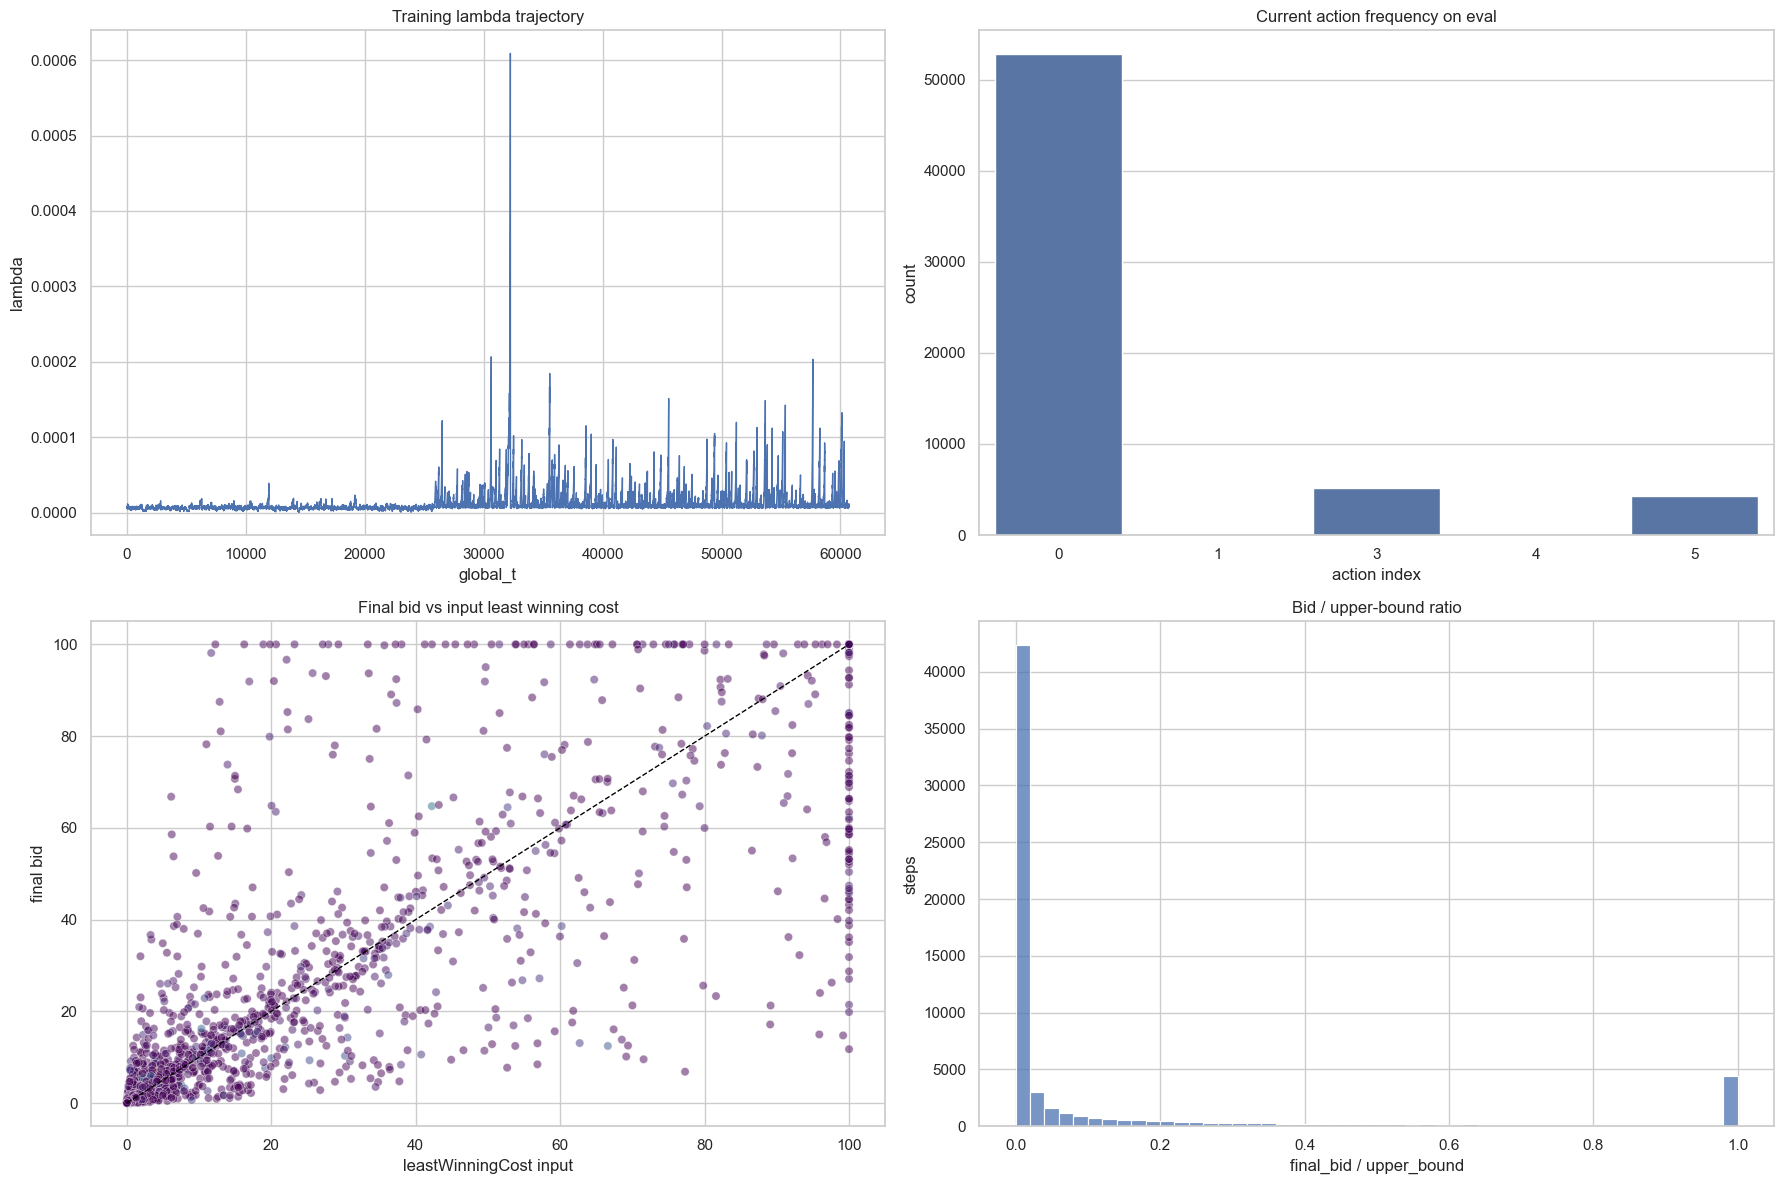

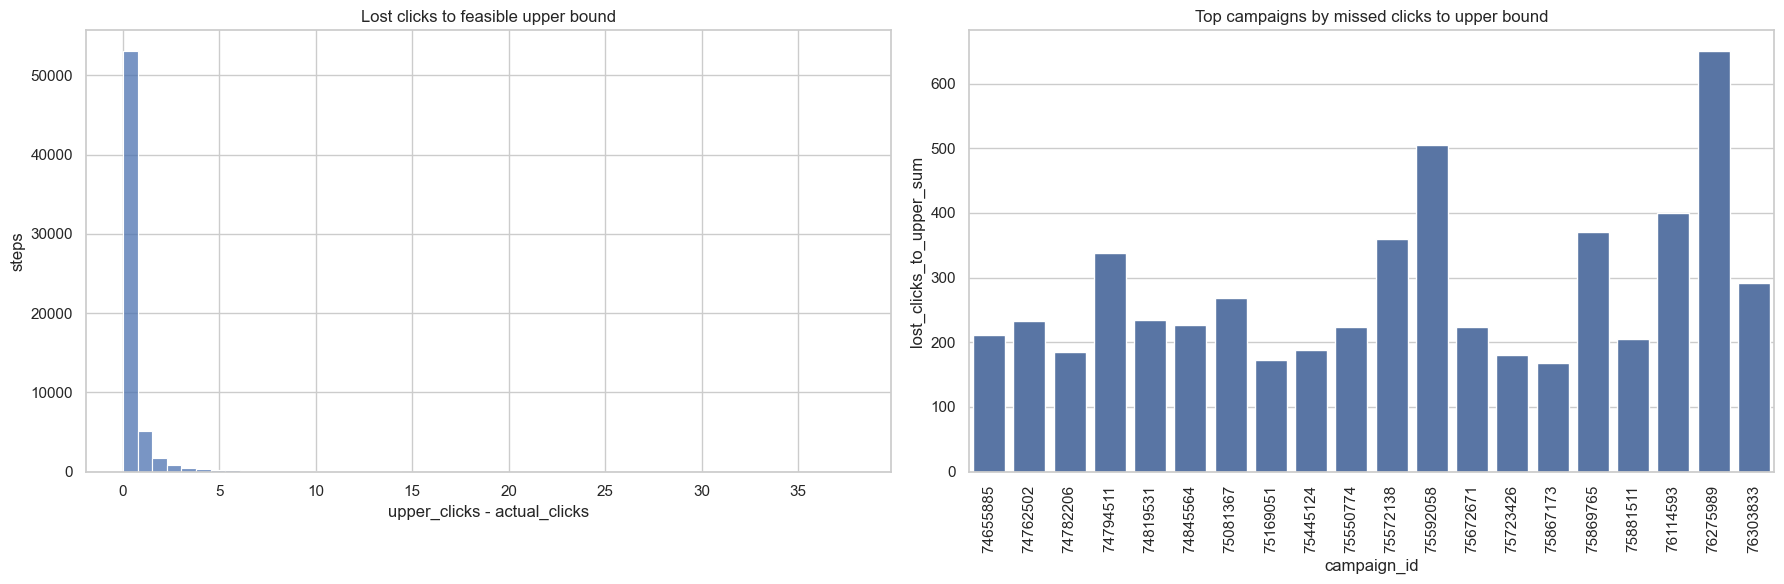

Saved figure: /Users/amsafin/code/local_ml/rl/bat-autobidding-benchmark/example_notebooks/experiments/exp_train_test_drlb_dqn_smooth/outputs/smooth_hybrid_train_test_debug/smooth_hybrid_train_test_debug_overview.png
Saved figure: /Users/amsafin/code/local_ml/rl/bat-autobidding-benchmark/example_notebooks/experiments/exp_train_test_drlb_dqn_smooth/outputs/smooth_hybrid_train_test_debug/smooth_hybrid_train_test_debug_counterfactuals.png


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

plot_train_df = train_diagnostics_df.copy()
plot_train_df = plot_train_df.replace([np.inf, -np.inf], np.nan)

axes[0, 0].plot(plot_train_df["global_t"], plot_train_df["lambda"], linewidth=1.0)
axes[0, 0].set_title("Training lambda trajectory")
axes[0, 0].set_xlabel("global_t")
axes[0, 0].set_ylabel("lambda")

sns.barplot(
    data=joined_debug_df["current_action"].value_counts().sort_index().rename_axis("action").reset_index(name="count"),
    x="action",
    y="count",
    ax=axes[0, 1],
)
axes[0, 1].set_title("Current action frequency on eval")
axes[0, 1].set_xlabel("action index")
axes[0, 1].set_ylabel("count")

sample_df = joined_debug_df.sample(min(5000, len(joined_debug_df)), random_state=42) if not joined_debug_df.empty else joined_debug_df
sns.scatterplot(
    data=sample_df,
    x="least_winning_cost_input",
    y="final_bid",
    hue="won_clicks",
    palette="viridis",
    alpha=0.5,
    ax=axes[1, 0],
    legend=False,
)
max_axis_value = float(
    np.nanmax(
        [
            sample_df["least_winning_cost_input"].max() if not sample_df.empty else 0.0,
            sample_df["final_bid"].max() if not sample_df.empty else 0.0,
        ]
    )
)
axes[1, 0].plot([0, max_axis_value], [0, max_axis_value], linestyle="--", color="black", linewidth=1.0)
axes[1, 0].set_title("Final bid vs input least winning cost")
axes[1, 0].set_xlabel("leastWinningCost input")
axes[1, 0].set_ylabel("final bid")

sns.histplot(joined_debug_df["bid_to_upper_ratio"].dropna(), bins=50, ax=axes[1, 1])
axes[1, 1].set_title("Bid / upper-bound ratio")
axes[1, 1].set_xlabel("final_bid / upper_bound")
axes[1, 1].set_ylabel("steps")

fig.tight_layout()
fig.savefig(FIG_MAIN_PATH, dpi=150, bbox_inches="tight")
plt.show()

fig2, axes2 = plt.subplots(1, 2, figsize=(18, 6))

sns.histplot(counterfactual_df["lost_clicks_to_upper"], bins=50, ax=axes2[0])
axes2[0].set_title("Lost clicks to feasible upper bound")
axes2[0].set_xlabel("upper_clicks - actual_clicks")
axes2[0].set_ylabel("steps")

top_loss_df = campaign_summary_df.nlargest(20, "lost_clicks_to_upper_sum") if "lost_clicks_to_upper_sum" in campaign_summary_df.columns else campaign_summary_df.head(20)
sns.barplot(data=top_loss_df, x="campaign_id", y="lost_clicks_to_upper_sum", ax=axes2[1])
axes2[1].set_title("Top campaigns by missed clicks to upper bound")
axes2[1].set_xlabel("campaign_id")
axes2[1].set_ylabel("lost_clicks_to_upper_sum")
axes2[1].tick_params(axis="x", rotation=90)

fig2.tight_layout()
fig2.savefig(FIG_COUNTERFACTUAL_PATH, dpi=150, bbox_inches="tight")
plt.show()

print("Saved figure:", FIG_MAIN_PATH)
print("Saved figure:", FIG_COUNTERFACTUAL_PATH)


In [9]:
action_cols = [f"q_{idx}" for idx in range(7)]
q_summary_df = pd.DataFrame(
    {
        "action": list(range(7)),
        "beta": [-0.08, -0.03, -0.01, 0.0, 0.01, 0.03, 0.08],
        "mean_q": [joined_debug_df[col].mean() for col in action_cols],
        "p95_q": [joined_debug_df[col].quantile(0.95) for col in action_cols],
        "is_edge": [idx in (0, 6) for idx in range(7)],
    }
)

interesting_steps_df = (
    joined_debug_df.assign(abs_clip_gap=lambda df: df["clip_gap"].abs())
    .sort_values(["won_clicks", "abs_clip_gap"], ascending=[False, False])
    .head(20)
)

display(q_summary_df)
display(counterfactual_df.sort_values("lost_clicks_to_upper", ascending=False).head(20))
display(interesting_steps_df)


,action,beta,mean_q,p95_q,is_edge
0,0,-0.08,6.399235,10.130322,True
1,1,-0.03,5.742538,9.865883,False
2,2,-0.01,5.714743,9.128666,False
3,3,0.00,5.319440,7.766091,False
4,4,0.01,6.015917,9.661480,False
5,5,0.03,5.949010,9.433385,False
6,6,0.08,5.808472,9.071057,True


,campaign_id,curr_timestamp,actual_spend_frontier,actual_clicks_frontier,upper_spend_frontier,upper_clicks_frontier,upper_contacts_frontier,upper_visibility_frontier,lost_clicks_to_upper,lost_spend_to_upper
14258,75592058,529750800,0.0,0.0,258.34,37.941681,0.914869,255.087387,37.941681,258.34
14259,75592058,529754400,0.0,0.0,240.96,35.531885,0.857123,244.525470,35.531885,240.96
14260,75592058,529758000,0.0,0.0,225.95,34.371277,0.827095,241.571248,34.371277,225.95
14261,75592058,529761600,0.0,0.0,188.37,32.404662,0.779479,238.669199,32.404662,188.37
14266,75592058,529779600,0.0,0.0,210.10,30.395035,0.731402,225.741491,30.395035,210.10
36259,76503842,529902000,0.0,0.0,158.61,30.313513,0.365464,82.865227,30.313513,158.61
14265,75592058,529776000,0.0,0.0,208.36,30.113258,0.715027,232.213301,30.113258,208.36
14262,75592058,529765200,0.0,0.0,171.80,28.509777,0.682945,215.679756,28.509777,171.80
14256,75592058,529743600,0.0,0.0,166.79,28.222058,0.675363,198.261336,28.222058,166.79
14263,75592058,529768800,0.0,0.0,177.40,27.580081,0.659296,216.360227,27.580081,177.40


,campaign_id,curr_timestamp,hour_index,balance,initial_balance,ctr_input,least_winning_cost_input,lambda_before_bid,current_action,current_beta,argmax_action,argmax_beta,raw_bid,final_bid,upper_bound,clip_gap,clipped_by_upper,clipped_to_min,bid_to_upper_ratio,bid_to_prev_cost_ratio,state_rem_budget_ratio,state_elapsed_time_ratio,state_initial_budget_scale,state_t_step,state_rol,state_bcr,state_cpm,state_wr,state_rewards_prev_t,q_0,q_1,q_2,q_3,q_4,q_5,q_6,hist_bid,won_spend,won_clicks,balance_after_step,won_anything,abs_clip_gap
25998,76173148,530200800,123,1577.273826,1632.96,0.043734,52.049001,0.000505,5,0.03,5,0.03,84.116090,84.116090,100.0,0.000000,False,False,0.841161,1.616094,0.982074,0.509100,0.739876,123.0,117.0,0.001240,1990.268066,1.0,0.194179,5.019671,5.001332,5.012025,4.982702,5.006565,5.195102,4.998141,84.116090,313.458811,39.943694,1263.815015,True,0.000000
19479,76381557,530200800,120,503.011538,616.32,0.069905,100.000000,0.000150,0,-0.08,0,-0.08,421.554746,100.000000,100.0,321.554746,True,False,1.000000,1.000000,0.947829,0.713231,0.642539,120.0,48.0,0.000517,302.235229,1.0,0.047831,3.608998,2.112545,2.462896,3.191034,2.599635,2.788609,3.079050,100.000000,369.295195,19.751862,133.716344,True,321.554746
8836,74762502,530204400,148,6554.609869,6675.84,0.035199,3.943676,0.005011,5,0.03,5,0.03,6.819334,6.819334,100.0,0.000000,False,False,0.068193,1.729182,0.981532,0.877530,0.880640,148.0,20.0,0.000974,6391.466309,1.0,8.612833,5.019671,5.001332,5.012025,4.982702,5.006565,5.195102,4.998141,6.819334,11.877635,16.970820,6542.732234,True,0.000000
25999,76173148,530204400,124,1263.815015,1632.96,0.041747,84.116090,0.000520,5,0.03,5,0.03,77.955459,77.955459,100.0,0.000000,False,False,0.779555,0.926760,0.948505,0.513266,0.739876,124.0,116.0,0.018008,28403.953125,1.0,6.225456,5.019671,5.001332,5.012025,4.982702,5.006565,5.195102,4.998141,77.955459,109.241212,15.251938,1154.573803,True,0.000000
35282,76305696,530280000,143,1852.463193,1929.60,0.009355,32.880367,0.001051,5,0.03,5,0.03,8.643642,8.643642,100.0,0.000000,False,False,0.086436,0.262882,0.960616,0.849398,0.756559,143.0,25.0,0.001735,3221.293213,1.0,4.271241,5.019671,5.001332,5.012025,4.982702,5.006565,5.195102,4.998141,8.643642,3.671713,13.881551,1848.791481,True,0.000000
57872,76303833,530010000,68,132.729283,138.24,0.074376,8.356646,0.010543,5,0.03,5,0.03,6.848753,6.848753,100.0,0.000000,False,False,0.068488,0.819558,0.963582,0.940687,0.493620,68.0,4.0,0.003022,403.731201,1.0,2.938255,4.561005,4.418260,4.495977,4.405658,4.448474,4.655010,4.461795,6.848753,1.697604,12.223175,131.031679,True,0.000000
24278,75738896,529880400,38,379.191143,380.16,0.142002,0.277185,0.075325,0,-0.08,0,-0.08,2.049121,2.049121,100.0,0.000000,False,False,0.020491,7.392601,0.997451,0.309299,0.594322,38.0,82.0,-0.000000,0.000000,0.0,0.000000,8.630122,8.348701,7.953809,6.670606,8.296718,8.093379,7.864816,2.049121,1.839233,11.339532,377.351910,True,0.000000
8832,74762502,530190000,144,6579.189283,6675.84,0.041988,3.895555,0.004452,5,0.03,5,0.03,9.155655,9.155655,100.0,0.000000,False,False,0.091557,2.350282,0.985354,0.853720,0.880640,144.0,24.0,0.000801,5275.079102,1.0,6.502638,5.019671,5.001332,5.012025,4.982702,5.006565,5.195102,4.998141,9.155655,9.284104,10.787668,6569.905179,True,0.000000
8835,74762502,530200800,147,6558.945050,6675.84,0.019763,7.184328,0.004865,5,0.03,5,0.03,3.943676,3.943676,100.0,0.000000,False,False,0.039437,0.548928,0.982763,0.871577,0.880640,147.0,21.0,0.000696,4568.661621,1.0,10.080606,5.019671,5.001332,5.012025,4.982702,5.006565,5.195102,4.998141,3.943676,4.335181,10.508995,6554.609869,True,0.000000
41766,76114593,529848000,25,452.050752,452.42,0.187600,0.701312,0.222688,5,0.03,5,0.03,0.915692,0.915692,100.0,0.000000,False,False,0.009157,1.305685,0.998920,0.516620,0.611682,25.0,23.0,0.000360,162.767700,1.0,2.701916,4.778696,4.705641,4.752773,4.682975,4.725592,4.916633,4.720812,0.915692,0.707561,10.484553,451.343191,True,0.000000


## Reading The Outputs

Use the saved artifacts like this:

- `*_training_diagnostics.csv`: check whether training already drove `lambda` or losses into a strange regime.
- `*_eval_steps.csv`: inspect `raw_bid`, `final_bid`, `upper_bound`, `current_action`, `argmax_action`, and `q_0...q_6`.
- `*_counterfactual_steps.csv`: if `lost_clicks_to_upper` is often positive while `bid_to_upper_ratio` stays low, that is evidence of underbidding.
- `*_campaign_summary.csv`: shows which campaigns lose the most clicks because bids stay below the feasible upper bound.

A few interpretations are especially useful:

- `edge_action_rate` high: the action grid may be too narrow or the policy keeps saturating at the boundaries.
- `clip_upper_rate` high: the model may be aggressive, but the environment clamps bids anyway.
- `argmax_action` concentrated near the middle with flat `mean_q`: the policy may be weak or indifferent.
- high `lost_clicks_to_upper` with low `clip_upper_rate`: stronger evidence of systematic underbidding.
